Images shape: (200, 64, 64, 3)
[[20 11]
 [15 14]]
              precision    recall  f1-score   support

           0       0.57      0.65      0.61        31
           1       0.56      0.48      0.52        29

    accuracy                           0.57        60
   macro avg       0.57      0.56      0.56        60
weighted avg       0.57      0.57      0.56        60



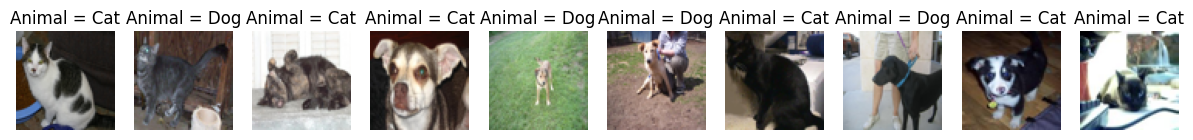

In [ ]:
import os
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt


# Dataset paths
cat_path = 'Cat/'
dog_path = 'Dog/'

# Check paths
if not os.path.exists(cat_path):
    print(f"Cat directory not found: {cat_path}")

if not os.path.exists(dog_path):
    print(f"Dog directory not found: {dog_path}")

# Load images
def load_images_and_labels(cat_path, dog_path):
    images = []
    labels = []

    # Load cat images
    for img in os.listdir(cat_path):
        img_path = os.path.join(cat_path, img)

        try:
            image = Image.open(img_path)
            image = image.convert('RGB')
            image = image.resize((64, 64))

            image = np.array(image)

            images.append(image)
            labels.append(0)

        except Exception as e:
            print(f"Skipping cat image: {img_path} - {e}")

    # Load dog images
    for img in os.listdir(dog_path):
        img_path = os.path.join(dog_path, img)

        try:
            image = Image.open(img_path)
            image = image.convert('RGB')
            image = image.resize((64, 64))

            image = np.array(image)

            images.append(image)
            labels.append(1)

        except Exception as e:
            print(f"Skipping dog image: {img_path} - {e}")

    images_array = np.array(images)
    labels_array = np.array(labels)

    print("Images shape:", images_array.shape)

    return images_array, labels_array


# Load dataset
if os.path.exists(cat_path) and os.path.exists(dog_path):

    images, labels = load_images_and_labels(cat_path, dog_path)

    if images.size > 0:

        # Flatten images
        num_samples, img_height, img_width, num_channels = images.shape

        X = images.reshape(num_samples,
                           img_height * img_width * num_channels)

        # Split dataset
        X_train, X_test, y_train, y_test = train_test_split(
            X,
            labels,
            test_size=0.3,
            random_state=42
        )

        # Train model
        svm_model = SVC(kernel='rbf')

        svm_model.fit(X_train, y_train)

        # Predict
        y_pred = svm_model.predict(X_test)

        # Results
        print(confusion_matrix(y_test, y_pred))
        print(classification_report(y_test, y_pred))

        # Visualization
        def visualize_predictions(X_test, y_pred, num_images=10):

            plt.figure(figsize=(15, 5))

            for i in range(num_images):

                plt.subplot(1, num_images, i + 1)

                plt.imshow(
                    X_test[i].reshape(
                        img_height,
                        img_width,
                        num_channels
                    )
                )

                plt.title(
                    'Animal = ' +
                    ('Dog' if y_pred[i] == 1 else 'Cat')
                )

                plt.axis('off')

            plt.show()

        visualize_predictions(X_test, y_pred)

    else:
        print("No valid images loaded.")

else:
    print("Dataset folders missing.")